In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # embed TrueType fonts, keep text editable
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans'] 

*Calculating the metrics:*

In [3]:
day = 'd35'
to_counts = 'populations'
# 'clusters' / 'populations'

In [4]:
# -----------------------------
# reading the cluster counts
# -----------------------------

if day == 'd35':
    if to_counts == 'clusters':
        main_path = '/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/DATA/patient_data_excels/d35/FinalClusterCounts.csv'
    else:
        # main_path = '/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/DATA/patient_data_excels/d35/FinalPopulationCounts_v2026_02_27_ClustersExcluded.csv'
        main_path = '/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/DATA/patient_data_excels/d35/FinalClusterCounts.csv'
    metadata = pd.read_csv('/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/OTHER/Metadata/Mixed_Day35/cyCondor/cyCondor_OC_VC_d35_OCT2025_UPD.csv')
    d35_cohort_dict = dict(zip(metadata['ISH_ID_TPL_date_MERGED'], metadata['batch_coh']))
elif day == 'd100':
    if to_counts == 'clusters':
        main_path = '/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/DATA/patient_data_excels/d100/FinalClusterCounts.csv'
    else:
        main_path = '/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/DATA/patient_data_excels/d100/FinalPopulationCounts_v2026_02_11_ClustersExcluded.csv'
if to_counts == 'clusters':
    cluster_output = pd.read_csv(main_path, index_col='group_var')
else:
    # cluster_output = pd.read_csv(main_path, index_col='ISH_ID_TPL_date_MERGED')
    cluster_output = pd.read_csv(main_path, index_col='group_var')

if 'Unnamed: 0' in cluster_output.columns:
    cluster_output = cluster_output.drop(columns=['Unnamed: 0'])

if to_counts == 'populations':
    dict_renamer = {
        "ALL_res45_14":"Exclude",
        "ALL_res45_5":"Exclude",
        "ALL_res45_45":"B",
        "ALL_res45_37":"CD56bright NK CD8- GPR56-",
        "ALL_res45_38":"CD56bright NK CD8mid GPR56+",
        "ALL_res45_44":"CD56bright NK CD8mid GPR56+",
        "ALL_res45_40":"CD56bright NK CD8- GPR56+",
        "ALL_res45_43":"CD56bright NK CD8- GPR56+",
        "ALL_res55_47":"CD56bright NK CD8- GPR56+",
        "ALL_res55_52":"CD56bright NK CD8- GPR56+",
        "ALL_res45_34":"CD56dim NK CD57+ CD8+ GPR56+",
        "CD3pos_res60_16":"CD56dim NK CD57+ CD8+ GPR56+",
        "CD3pos_res60_29":"CD56dim NK CD57+ CD8- GPR56+",
        "CD3pos_res60_37":"CD56dim NK CD57+ CD8- GPR56+",
        "CD3pos_res60_54":"CD56dim NK CD57+ CD8- GPR56+",
        "CD3pos_res70_40":"CD56dim NK CD57+ CD8- GPR56+",
        "ALL_res45_35":"CD56dim NK CD57- CD8- GPR56+",
        "ALL_res55_42":"CD56dim NK CD57- CD8- GPR56+",
        "ALL_res55_49":"CD56dim NK CD57- CD8- GPR56+",
        "CD3pos_res60_44":"CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+",
        "CD3pos_res60_60":"CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+",
        "CD3pos_res70_49":"CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+",
        "CD3pos_res70_57":"CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+",
        "CD3pos_res60_21":"CD3+ CD56dim CD8+ CD45RA+ CD57+ GPR56+",
        "CD3pos_res60_27":"CD3+ CD56dim CD8+ CD45RA+ CD57+ GPR56+",
        "CD3pos_res60_41":"CD3+ CD56dim CD8+ CD45RA+ CD57+ GPR56+",
        "CD3pos_res60_14":"CD3+ CD56dim CD8+ CD45RAmid CD57+ GPR56+",
        "CD3pos_res60_19":"CD3+ CD56dim CD8+ CD45RAmid CD57+ GPR56+",
        "CD3pos_res60_20":"CD3+ CD56dim CD8+ CD45RAmid CD57+ GPR56+",
        "CD3pos_res60_22":"CD3+ CD56dim CD8dim CD45RA+ CD57+ GPR56+",
        "CD3pos_res60_35":"CD3+ CD56dim CD8dim CD45RA+ CD57+ GPR56+",
        "CD3pos_res60_51":"CD3+ CD56dim CD8dim CD45RA+ CD57+ GPR56+",
        "CD3pos_res70_1":"CD4 TCM CD27+ CD29+ HLA-DR-",
        "CD3pos_res70_8":"CD4 TCM CD27+ CD29+ HLA-DR-",
        "CD3pos_res70_9":"CD4 TCM CD27+ CD29+ HLA-DR+",
        "CD3pos_res60_23":"CD4 Naive",
        "CD3pos_res70_14":"CD4 TEM CD27dim CD29+ CD57- GPR56-",
        "CD3pos_res60_12":"CD4 TEM CD27dim CD29+ CD57+ GPR56-",
        "CD3pos_res60_17":"CD4 TEM CD27dim CD29+ CD57+ GPR56-",
        "CD3pos_res60_18":"CD4 TEM CD27dim CD29+ CD57+ GPR56-",
        "CD3pos_res60_13":"CD4 TEM CD27dim CD29+ CD57+ GPR56+",
        "CD3pos_res60_2":"CD4 TEM CD27- CD29+ CD57- GPR56-",
        "CD3pos_res60_3":"CD4 TEM CD27- CD29+ CD57- GPR56+",
        "CD3pos_res60_8":"CD4 TEM CD27- CD29+ CD57- GPR56+",
        "CD3pos_res60_48":"CD8 TEMRA CD27dim CD57+ GPR56+",
        "CD3pos_res60_38":"CD8 TEMRA CD27dim CD57- GPR56+",
        "CD3pos_res60_28":"CD8 TEMRA CD27- CD57+ GPR56+",
        "CD3pos_res60_52":"CD8 TEMRA CD27- CD57+ GPR56+",
        "CD3pos_res60_59":"CD8 TEMRA CD27- CD57+ GPR56+",
        "CD3pos_res60_45":"CD8 Naive",
        "CD3pos_res60_31":"CD8 TEM-adv0 CD27+ CD57- GPR56-",
        "CD3pos_res70_51":"CD8 TEM-adv0 CD27+ CD57- GPR56-",
        "CD3pos_res60_25":"CD8 TEM-adv0 CD27+ CD57+ GPR56-",
        "CD3pos_res60_46":"CD8dim TEM-adv0 CD27dim CD57- GPR56+",
        "CD3pos_res60_24":"CD8 TEM-adv1 CD27- CD56- CD57- GPR56-",
        "CD3pos_res70_58":"CD8 TEM-adv1 CD27+ CD56- CD57- GPR56-",
        "CD3pos_res70_43":"CD8 TEM-adv1 CD27+ CD56dim CD57- GPR56-",
        "CD3pos_res70_36":"CD8 TEM-adv1 CD27dim CD56- CD57+ GPR56-",
        "CD3pos_res60_15":"CD8 TEM-adv1 CD27dim CD56- CD57+ GPR56+",
        "CD3pos_res60_26":"CD8 TEM-adv1 CD27dim CD56- CD57+ GPR56+",
        "CD3pos_res60_33":"CD8 TEM-adv1 CD27dim CD56- CD57+ GPR56+",
        "CD3pos_res60_34":"CD8 TEM-adv1 CD27dim CD56- CD57+ GPR56+",
        "CD3pos_res60_42":"CD8 TEM-adv1 CD27dim CD56- CD57+ GPR56+",
        "CD3pos_res60_40":"CD8 TEM-adv1 CD27dim CD56- CD57- GPR56+",
        "CD3pos_res60_47":"CD8 TEM-adv1 CD27dim CD56- CD57- GPR56+",
        "CD3pos_res60_58":"CD8 TEM-adv1 CD27- CD56- CD57+ GPR56+",
        "CD3pos_res60_56":"CD8 TEM-adv1 CD27- CD56- CD57- GPR56+",
        "CD3pos_res60_57":"CD8 TEM-adv1 CD27- CD56- CD57- GPR56+",
        "CD3pos_res60_43":"CD8 TEM-adv2 CD57+ GPR56+",
        "CD3pos_res60_49":"CD8 TEM-adv2 CD57+ GPR56+",
        "CD3pos_res60_55":"CD8 TEM-adv2 CD57+ GPR56+",
        "CD3pos_res60_53":"Double Negative T TEMRA CD57+ GPR56+",
        "CD3pos_res70_56":"Double Negative T TEMRA CD57+ GPR56+",
        "CD3pos_res60_30":"Double Negative T TEM CD57- GPR56-",
        "CD3pos_res60_9":"gdT Vd1+ TEMRA CD27- CD57+ GPR56+",
        "CD3pos_res60_4":"gdT Vd1+ Naïve CD27+ CD57- GPR56-",
        "CD3pos_res60_5":"gdT Vd2+ Vg9+ TEM CD56dim CD57- GPR56+",
        "CD3pos_res60_10":"gdT Vd2+ Vg9+ TEM CD56dim CD57+ GPR56+",
        "CD3pos_res60_11":"gdT Vd2+ Vg9+ TEM CD56dim CD57+ GPR56+",
        "CD3pos_res60_6":"gdT Vd2+ Vg9+ TEM CD56dim CD57+ GPR56+",
        "CD3pos_res60_7":"gdT Vd2+ Vg9+ TEM CD56- CD57+ GPR56+",
        "ALL_res45_41":"DCs / HLA-DR+ APCs",
        "ALL_res55_44":"DCs / HLA-DR+ APCs",
        "ALL_res45_7":"DCs / HLA-DR+ APCs",
        "ALL_res55_39":"DCs / HLA-DR+ APCs",
        "ALL_res45_17":"Monocytes",
        "ALL_res55_12":"Monocytes",
        "ALL_res55_14":"Monocytes",
        "ALL_res55_16":"Monocytes",
        "ALL_res55_20":"Monocytes",
        "ALL_res55_21":"Monocytes",
        "ALL_res55_26":"Monocytes",
        "ALL_res55_8":"Monocytes",
        "ALL_res45_27":"Monocytes",
        "ALL_res55_15":"Monocytes",
        "ALL_res55_23":"Monocytes",
        "ALL_res55_45":"Monocytes",
        "ALL_res55_6":"Monocytes",
        "ALL_res45_42":"Monocytes",
        "ALL_res55_13":"Monocytes",
        "ALL_res55_4":"Monocytes",
    }

    dict_renamer_2 = {}
    for each in dict_renamer.values():
        dict_renamer_2[each] = list({k:v for k,v in dict_renamer.items() if v == each}.keys())

    for each in dict_renamer_2:
        cluster_output[each] = cluster_output[dict_renamer_2[each]].sum(axis = 1)
        cluster_output.drop(columns = dict_renamer_2[each], inplace = True)
    cluster_output.drop(columns = ['Exclude'], inplace = True)

# optional sanity check
count_per_sample = cluster_output.sum(axis=1).rename('count').reset_index()
count_per_sample.columns = ['sample', 'count']
print(count_per_sample['count'].describe())

# -----------------------------
# 1) normalize by sample size
# rows = samples, columns = clusters
# -----------------------------
cluster_output_normalized = (
    cluster_output.div(cluster_output.sum(axis=1).replace(0, pd.NA), axis=0)
    .fillna(0)
)

# -----------------------------
# define cohort sample lists
# -----------------------------
if day == 'd35':
    oc_keys = [s for s, coh in d35_cohort_dict.items() if coh == 'orig' and s in cluster_output_normalized.index]
    vc_keys = [s for s, coh in d35_cohort_dict.items() if coh == 'valid' and s in cluster_output_normalized.index]

    print(f'OC samples in matrix: {len(oc_keys)}')
    print(f'VC samples in matrix: {len(vc_keys)}')
    print(f'Total samples in matrix: {cluster_output_normalized.shape[0]}')

# -----------------------------
# 2) % samples >= 0.1%
# computed from sample-normalized matrix
# -----------------------------
threshold = 0.0005

presence_total = (cluster_output_normalized >= threshold).mean(axis=0)

if day == 'd35':
    presence_oc = (cluster_output_normalized.loc[oc_keys] >= threshold).mean(axis=0)
    presence_vc = (cluster_output_normalized.loc[vc_keys] >= threshold).mean(axis=0)

# -----------------------------
# 3) log2FC (VC vs OC)
# computed from sample-normalized matrix
# -----------------------------
# pseudocount prevents division by zero for clusters absent in one cohort
pseudocount = 1e-8

if day == 'd35':
    median_oc = cluster_output_normalized.loc[oc_keys].median(axis=0)
    median_vc = cluster_output_normalized.loc[vc_keys].median(axis=0)

    log2fc_vc_vs_oc = np.log2((median_vc + pseudocount) / (median_oc + pseudocount))

# -----------------------------
# 4) normalize within each cluster
# each cluster column sums to 1 across samples
# -----------------------------
cluster_dist = (
    cluster_output_normalized.div(cluster_output_normalized.sum(axis=0).replace(0, pd.NA), axis=1)
    .fillna(0)
)

# optional sanity check
# print(cluster_dist.sum(axis=0).head())

# -----------------------------
# 5) top5 contribution (global)
# from cluster_dist
# -----------------------------
top5_contribution = cluster_dist.apply(lambda x: x.nlargest(5).sum(), axis=0)

# -----------------------------
# 6) effective N
# from cluster_dist
# -----------------------------
effective_n = 1 / cluster_dist.pow(2).sum(axis=0)

# optional relative effective N
effective_n_rel = effective_n / cluster_dist.shape[0]

# -----------------------------
# 7) VC contribution
# from cluster_dist
# -----------------------------
if day == 'd35':
    vc_contribution = cluster_dist.loc[vc_keys].sum(axis=0)
    oc_contribution = cluster_dist.loc[oc_keys].sum(axis=0)  # optional sanity check
    # oc_contribution + vc_contribution should be ~1 for each cluster

# -----------------------------
# 8) assemble final table
# -----------------------------
final_output = pd.DataFrame(index=cluster_output.columns)

# presence columns
if day == 'd35':
    final_output[f'% samples with ≥ {threshold*100}%\ncells from cluster\nCohort 1, day 35'] = presence_oc.round(2)
    final_output[f'% samples with ≥ {threshold*100}%\ncells from cluster\nCohort 2, day 35'] = presence_vc.round(2)
    final_output[f'% samples with ≥ {threshold*100}%\ncells from cluster\nCohorts 1&2, day 35'] = presence_total.round(2)
elif day == 'd100':
    final_output[f'% samples with ≥ {threshold*100}%\ncells from cluster\nCohort 1, day 100'] = presence_total.round(2)

# log2FC
if day == 'd35':
    final_output['log2FC\nCohort 2 vs Cohort 1\n(median sample-\nnormalized abundance)'] = log2fc_vc_vs_oc.round(3)

# top5 global
final_output['Top 5 samples\ncontribution to cluster\n(global)'] = top5_contribution.round(3)

# effective N
final_output['Effective #\nof samples'] = effective_n.round(2)

# optional relative effective N
final_output['Relative\neffective #\nof samples'] = effective_n_rel.round(3)

# VC contribution
if day == 'd35':
    final_output['Cohort 2\ncontribution\nto cluster'] = vc_contribution.round(3)
    final_output['Cohort 1\ncontribution\nto cluster'] = 1 - final_output['Cohort 2\ncontribution\nto cluster']

# -----------------------------
# optional: sort rows
# -----------------------------
if day == 'd35':
    final_output = final_output.sort_values(
        by=[
            f'% samples with ≥ {threshold*100}%\ncells from cluster\nCohorts 1&2, day 35',
            'Relative\neffective #\nof samples'
        ],
        ascending=[False, False]
    )
else:
    final_output = final_output.sort_values(
        by=[
            f'% samples with ≥ {threshold*100}%\ncells from cluster\nCohort 1, day 100',
            'Relative\neffective #\nof samples'
        ],
        ascending=[False, False]
    )

print(final_output.head())

count    2.530000e+02
mean     2.531412e+05
std      2.504679e+05
min      1.832000e+03
25%      6.454000e+04
50%      1.446730e+05
75%      3.823920e+05
max      1.196624e+06
Name: count, dtype: float64
OC samples in matrix: 130
VC samples in matrix: 123
Total samples in matrix: 253
                              % samples with ≥ 0.05%\ncells from cluster\nCohort 1, day 35  \
Monocytes                                                                   1.0              
CD56dim NK CD57- CD8- GPR56+                                                1.0              
CD56bright NK CD8- GPR56+                                                   1.0              
DCs / HLA-DR+ APCs                                                          1.0              
CD56bright NK CD8- GPR56-                                                   1.0              

                              % samples with ≥ 0.05%\ncells from cluster\nCohort 2, day 35  \
Monocytes                                               

*Recording the table:*

In [10]:
base_dir = '/g/scb2/zaugg/stapran/24_09_FACS_Project_Iter2/SCRIPTS/Biomarker_Analysis/251102_NewStoryLine/FinalPlotsPaper/250924_HowUnbiasedIsClustering'
final_output_csv = final_output.copy()
final_output_csv.columns = [element.replace('\n',' ') for element in final_output_csv.columns]
# final_output_csv.to_csv(f'{base_dir}/{day}_{to_counts}_distribution_check.csv')

*Plotting the metrics:*

/tmp/ipykernel_2194908/3665039214.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


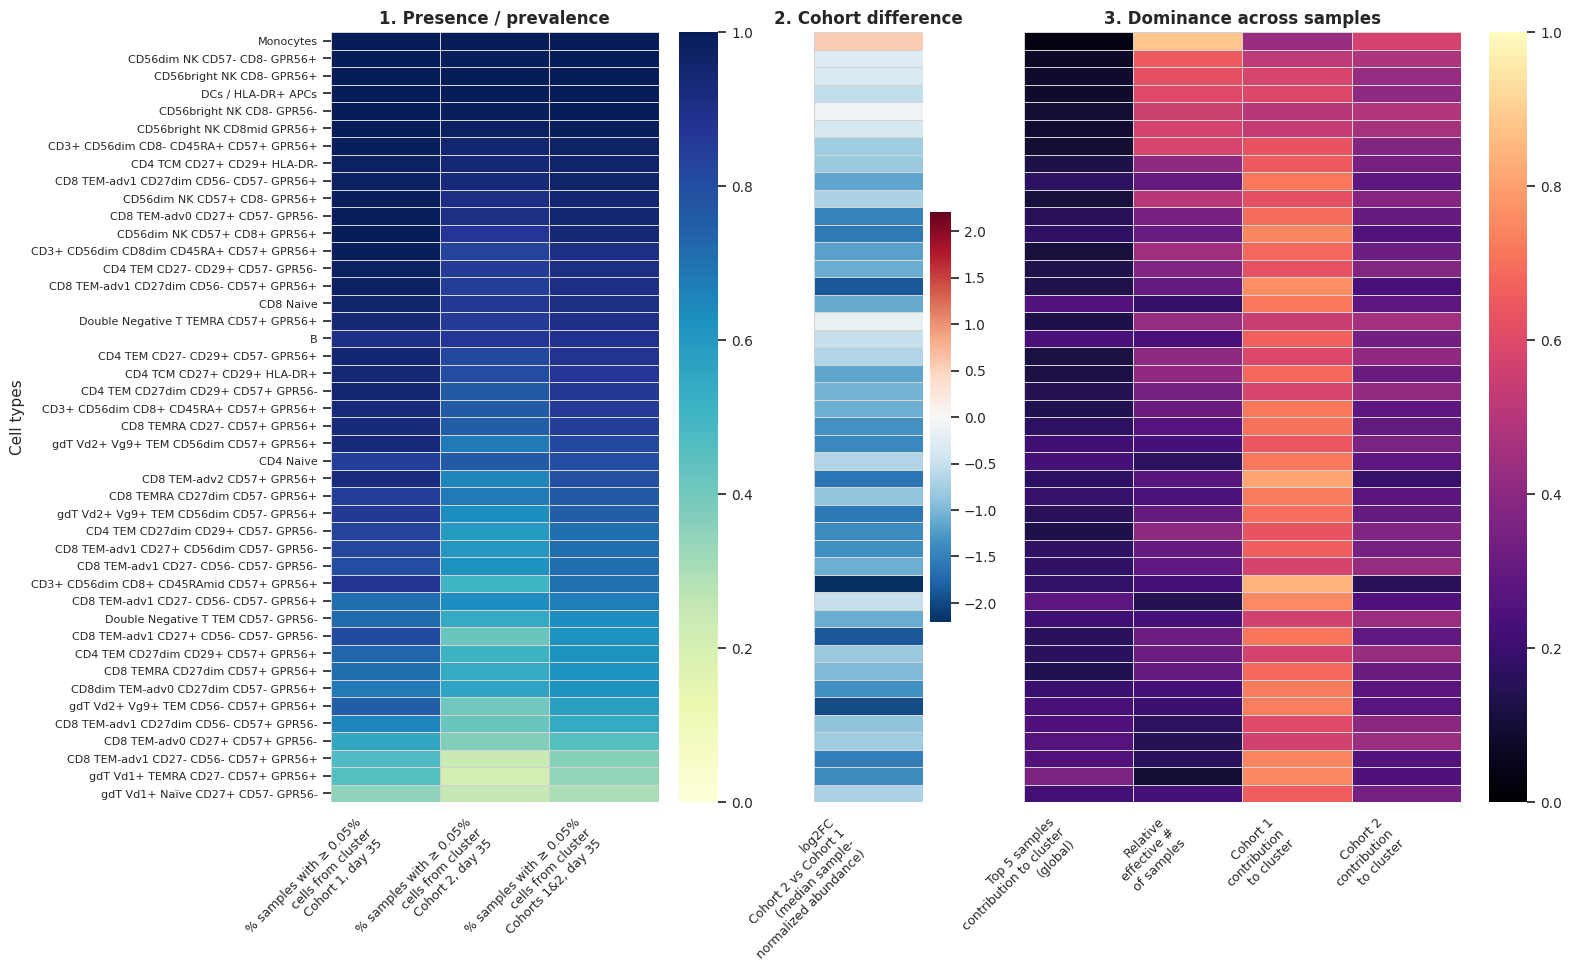

In [14]:
if day == 'd35':
    # -----------------------------------------
    # Example: split final_output into 3 groups
    # -----------------------------------------

    presence_cols = [
        col for col in final_output.columns
        if '% samples with ≥' in col
    ]

    cohort_diff_cols = [
        col for col in final_output.columns
        if 'log2FC' in col
    ]

    dominance_cols = [
        col for col in final_output.columns
        if ('Top 5 samples' in col) or ('Relative\neffective #' in col) or ('Cohort 1\ncontribution' in col or 'Cohort 2\ncontribution' in col)
    ]

    presence_df = final_output[presence_cols].copy()
    cohort_diff_df = final_output[cohort_diff_cols].copy()
    dominance_df = final_output[dominance_cols].copy()

    # -----------------------------------------
    # Optional: choose a row order
    # -----------------------------------------
    # Example: sort by total prevalence, then effective N
    sort_col1 = [c for c in final_output.columns if 'Cohorts 1&2' in c and '% samples with ≥' in c]
    sort_col2 = [c for c in final_output.columns if 'Relative\neffective #' in c]

    if len(sort_col1) > 0 and len(sort_col2) > 0:
        row_order = final_output.sort_values(
            by=[sort_col1[0], sort_col2[0]],
            ascending=[False, False]
        ).index
    else:
        row_order = final_output.index

    presence_df = presence_df.loc[row_order]
    cohort_diff_df = cohort_diff_df.loc[row_order]
    dominance_df = dominance_df.loc[row_order]

    # -----------------------------------------
    # Plotting
    # -----------------------------------------
    sns.set(style='white', font_scale=0.9)

    n_rows = final_output.shape[0]

    fig_height = max(10, n_rows * 0.22)
    fig, axes = plt.subplots(
        ncols=3,
        figsize=(16, fig_height),
        gridspec_kw={
            'width_ratios': [
                max(1.8, presence_df.shape[1] * 1.2),
                max(1.2, cohort_diff_df.shape[1] * 1.2),
                max(1.8, dominance_df.shape[1] * 1.2),
            ],
            'wspace': 0.2
        },
        sharey=True
    )

    # 1. Presence / prevalence
    # if to_counts == 'populations':
    #     replacement_dict = {
    #         'LowLevel ': '',
    #         'CD4 CCR7mid CD45RA-': 'CD4 TCM',
    #         'Naive': 'Naïve',
    #         'CD8 TEM': 'CD8 TEM-adv0',
    #         'CD8dim TEM': 'CD8dim TEM-adv0',
    #         'CD8 CCR7- CD45RA+': 'CD8 TEMRA',
    #         'CD8 CCR7- CD45RAmid/+': 'CD8 TEM-adv2',
    #         'CD8 CCR7- CD45RAmid': 'CD8 TEM-adv1',
    #     }
    #     new_names = list(presence_df.index)
    #     for key, value in replacement_dict.items():
    #         new_names = [element.replace(key, value) for element in new_names]
    # else:
    new_names = list(presence_df.index)

    ax1 = axes[0]
    sns.heatmap(
        presence_df,
        ax=ax1,
        cmap='YlGnBu',
        vmin=0,
        vmax=1,
        cbar=True,
        linewidths=0.5,
        linecolor='lightgrey',
        yticklabels=False
    )
    ax1.set_title('1. Presence / prevalence', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylabel('Cluster' if to_counts == 'clusters' else 'Cell types', fontsize=11)

    # 2. Cohort difference
    ax2 = axes[1]
    if cohort_diff_df.shape[1] > 0:
        max_abs_fc = np.nanmax(np.abs(cohort_diff_df.to_numpy()))
        if np.isnan(max_abs_fc) or max_abs_fc == 0:
            max_abs_fc = 1

        sns.heatmap(
            cohort_diff_df,
            ax=ax2,
            cmap='RdBu_r',
            center=0,
            vmin=-max_abs_fc,
            vmax=max_abs_fc,
            cbar=True,
            linewidths=0.5,
            linecolor='lightgrey',
            yticklabels=False
        )
    ax2.set_title('2. Cohort difference', fontsize=12, fontweight='bold')
    ax2.set_xlabel('')
    ax2.set_ylabel('')

    # 3. Dominance across samples
    ax3 = axes[2]

    # Since these columns are on different scales, rescale them column-wise for plotting
    dominance_plot_df = dominance_df.copy()
    dominance_plot_df = dominance_plot_df[[
        'Top 5 samples\ncontribution to cluster\n(global)',
        'Relative\neffective #\nof samples',
        'Cohort 1\ncontribution\nto cluster',
        'Cohort 2\ncontribution\nto cluster'
    ]]

    sns.heatmap(
        dominance_plot_df,
        ax=ax3,
        cmap='magma',
        vmin=0,
        vmax=1,
        cbar=True,
        linewidths=0.5,
        linecolor='lightgrey',
        yticklabels=False
    )
    ax3.set_title('3. Dominance across samples', fontsize=12, fontweight='bold')
    ax3.set_xlabel('')
    ax3.set_ylabel('')


    # NOW force y labels on the first facet only
    ax1.set_yticks(np.arange(len(new_names)) + 0.5)
    ax1.set_yticklabels(new_names, rotation=0, fontsize=8)
    ax1.tick_params(axis='y', which='both', left=True, labelleft=True)

    ax2.tick_params(axis='y', which='both', left=False, labelleft=False)
    ax3.tick_params(axis='y', which='both', left=False, labelleft=False)

    # Rotate x labels
    for ax in axes:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{base_dir}/{day}_{to_counts}_heatmap.png', bbox_inches = 'tight')
    plt.savefig(f'{base_dir}/{day}_{to_counts}_heatmap.pdf', bbox_inches = 'tight')
    plt.show()

else:
    presence_cols = [
        col for col in final_output.columns
        if '% samples with ≥' in col
    ]

    dominance_cols = [
        col for col in final_output.columns
        if ('Top 5 samples' in col) or ('Relative\neffective #' in col)
    ]

    presence_df = final_output[presence_cols].copy()
    dominance_df = final_output[dominance_cols].copy()

    # -----------------------------------------
    # Optional: choose a row order
    # -----------------------------------------
    # Example: sort by total prevalence, then effective N
    sort_col1 = [c for c in final_output.columns if 'Cohort 1' in c and '% samples with ≥' in c]
    sort_col2 = [c for c in final_output.columns if 'Relative\neffective #' in c]

    if len(sort_col1) > 0 and len(sort_col2) > 0:
        row_order = final_output.sort_values(
            by=[sort_col1[0], sort_col2[0]],
            ascending=[False, False]
        ).index
    else:
        row_order = final_output.index

    presence_df = presence_df.loc[row_order]
    dominance_df = dominance_df.loc[row_order]

    # -----------------------------------------
    # Plotting
    # -----------------------------------------
    sns.set(style='white', font_scale=0.9)

    n_rows = final_output.shape[0]

    fig_height = max(10, n_rows * 0.22)
    fig, axes = plt.subplots(
        ncols=2,
        figsize=(8, fig_height),
        gridspec_kw={
            'width_ratios': [
                max(1.8, presence_df.shape[1] * 1.2),
                max(1.8, dominance_df.shape[1] * 1.2),
            ],
            'wspace': 0.2
        },
        sharey=True
    )

    # 1. Presence / prevalence
    if to_counts == 'populations':
        replacement_dict = {
            'LowLevel ': '',
            'CD4 CCR7mid CD45RA-': 'CD4 TCM',
            'CD4 (Tregs) CCR7mid CD45RA-': 'CD4 Tregs',
            'CD8 CCR7- CD45RA+': 'CD8 TEMRA',
            'CD8 TEM': 'CD8 TEM-adv0',
            'CD8 CCR7- CD45RAmid/+': 'CD8 TEM-adv2',
            'CD8 CCR7- CD45RAmid': 'CD8 TEM-adv1',
        }
        new_names = list(presence_df.index)
        for key, value in replacement_dict.items():
            new_names = [element.replace(key, value) for element in new_names]
    else:
        new_names = list(presence_df.index)

    ax1 = axes[0]
    sns.heatmap(
        presence_df,
        ax=ax1,
        cmap='YlGnBu',
        vmin=0,
        vmax=1,
        cbar=True,
        linewidths=0.5,
        linecolor='lightgrey',
        yticklabels=False
    )
    ax1.set_title('1. Presence / prevalence', fontsize=12, fontweight='bold')
    ax1.set_xlabel('')
    ax1.set_ylabel('Cluster' if to_counts == 'clusters' else 'Cell types', fontsize=11)

    # 3. Dominance across samples
    ax3 = axes[1]

    # Since these columns are on different scales, rescale them column-wise for plotting
    dominance_plot_df = dominance_df.copy()

    sns.heatmap(
        dominance_plot_df,
        ax=ax3,
        cmap='magma',
        vmin=0,
        vmax=1,
        cbar=True,
        linewidths=0.5,
        linecolor='lightgrey',
        yticklabels=False
    )
    ax3.set_title('2. Dominance across samples', fontsize=12, fontweight='bold')
    ax3.set_xlabel('')
    ax3.set_ylabel('')


    # NOW force y labels on the first facet only
    ax1.set_yticks(np.arange(len(new_names)) + 0.5)
    ax1.set_yticklabels(new_names, rotation=0, fontsize=8)
    ax1.tick_params(axis='y', which='both', left=True, labelleft=True)

    ax3.tick_params(axis='y', which='both', left=False, labelleft=False)

    # Rotate x labels
    for ax in axes:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'{base_dir}/{day}_{to_counts}_heatmap.png', bbox_inches = 'tight')
    plt.show()

In [13]:
dominance_df.columns

Index(['Top 5 samples\ncontribution to cluster\n(global)',
       'Relative\neffective #\nof samples',
       'Cohort 2\ncontribution\nto cluster',
       'Cohort 1\ncontribution\nto cluster'],
      dtype='object')

*Plotting the % samples >= 0.01% VS effective N*

In [11]:
plot_df = pd.DataFrame(index=cluster_output.columns)

# total cluster size (raw counts)
plot_df['cluster_size'] = cluster_output.sum(axis=0)

# presence (total)
if day == 'd35':
    presence_col = [c for c in final_output.columns if 'Cohorts 1&2' in c and '% samples with ≥' in c][0]
else:
    presence_col = [c for c in final_output.columns if 'Cohort 1' in c and '% samples with ≥' in c][0]
plot_df['presence'] = final_output[presence_col]

# effective N
eff_col = [c for c in final_output.columns if 'Relative\neffective #' in c][0]
plot_df['relative_effective_n'] = final_output[eff_col]

# log2FC (if available)
fc_cols = [c for c in final_output.columns if 'log2FC' in c]
if len(fc_cols) > 0:
    plot_df['log2fc'] = final_output[fc_cols[0]]

# optional: VC contribution
vc_cols = [c for c in final_output.columns if 'Cohort 2\ncontribution' in c]
if len(vc_cols) > 0:
    plot_df['vc_contribution'] = final_output[vc_cols[0]]

# remove zeros / NaNs if needed
plot_df = plot_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['relative_effective_n'])

# if to_counts == 'populations':
#     if day == 'd35':
#         replacement_dict = {
#             'LowLevel ': '',
#             'CD4 CCR7mid CD45RA-': 'CD4 TCM',
#             'Naive': 'Naïve',
#             'CD8 TEM': 'CD8 TEM-adv0',
#             'CD8dim TEM': 'CD8dim TEM-adv0',
#             'CD8 CCR7- CD45RA+': 'CD8 TEMRA',
#             'CD8 CCR7- CD45RAmid/+': 'CD8 TEM-adv2',
#             'CD8 CCR7- CD45RAmid': 'CD8 TEM-adv1',
#         }
#     elif day == 'd100':
#         replacement_dict = {
#             'LowLevel ': '',
#             'CD4 CCR7mid CD45RA-': 'CD4 TCM',
#             'CD4 (Tregs) CCR7mid CD45RA-': 'CD4 Tregs',
#             'CD8 CCR7- CD45RA+': 'CD8 TEMRA',
#             'CD8 TEM': 'CD8 TEM-adv0',
#             'CD8 CCR7- CD45RAmid/+': 'CD8 TEM-adv2',
#             'CD8 CCR7- CD45RAmid': 'CD8 TEM-adv1',
#         }
#     new_names = list(plot_df.index)
#     for key, value in replacement_dict.items():
#         new_names = [element.replace(key, value) for element in new_names]
# else:
#     new_names = list(plot_df.index)

def split_text_by_three_words(text, elements_per_line):
    """
    Split a string into substrings of 3 words each,
    joined by newline characters.
    """
    words = text.split()
    lines = [' '.join(words[i:i+elements_per_line]) for i in range(0, len(words), elements_per_line)]
    return '\n'.join(lines)
new_names = [split_text_by_three_words(element,3) for element in new_names]

plot_df.index = new_names

*Cluster size vs relative effective N*

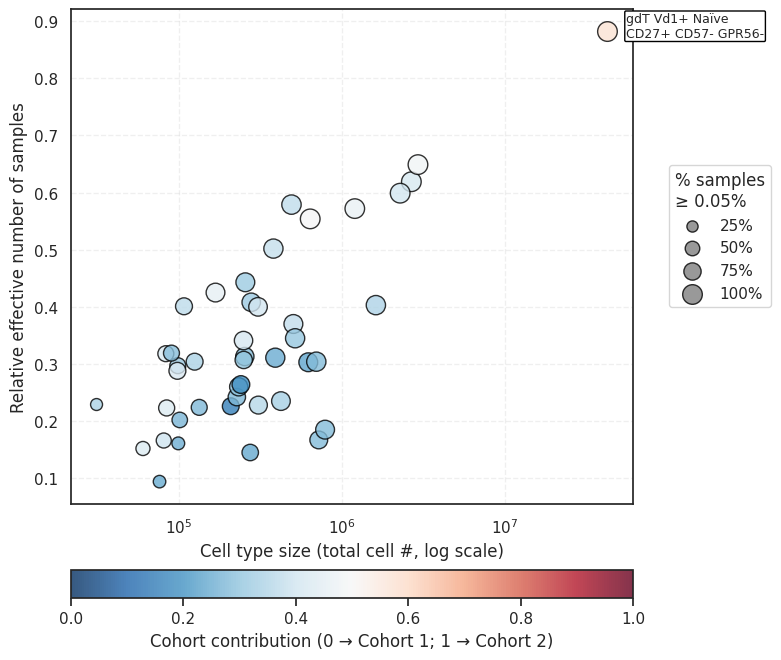

In [12]:
if day == 'd35':
    sns.set(style='white', font_scale=1.0)
    plt.figure(figsize=(8, 7))
    # plt.axhline(0.25, linestyle='--', color='darkgreen', alpha=0.6)
    # plt.axhline(0.50, linestyle='--', color='darkgreen', alpha=0.6)
    sizes = 20 + 180 * plot_df['presence']

    # vmax = np.max(np.abs(plot_df['vc_contribution']))
    # vmin = -vmax
    scatter = plt.scatter(
        plot_df['cluster_size'],
        plot_df['relative_effective_n'],
        c=plot_df.get('vc_contribution', None),   # color by log2FC if available
        s = sizes,
        cmap='RdBu_r',
        edgecolor='black',
        alpha=0.8,
        vmin = 0,
        vmax = 1
    )

    plt.xscale('log')  # IMPORTANT for wide size range
    plt.xlabel('Cluster size (total cell #, log scale)' if to_counts == 'clusters' else 'Cell type size (total cell #, log scale)')
    plt.ylabel('Relative effective number of samples')
    plt.title('')

    # colorbar if log2FC exists
    if 'log2fc' in plot_df.columns:
        cbar = plt.colorbar(scatter, location = 'bottom', pad = 0.1)
        cbar.set_label('Cohort contribution (0 → Cohort 1; 1 → Cohort 2)')

    size_values = [0.25, 0.5, 0.75, 1.0]  # fractions of samples
    for val in size_values:
        plt.scatter(
            [], [],  # empty data
            s=20 + 180 * val,
            color='gray',
            edgecolor='black',
            alpha=0.8,
            label=f'{int(val * 100)}%'
        )

    plt.legend(
        title=f'% samples\n≥ {threshold * 100}%',
        loc='upper left',
        bbox_to_anchor=(1.05, 0.7),
        # borderaxespad=0.
        frameon=True
    )

    for i, row in plot_df.iterrows():
        if row['relative_effective_n'] > 0.75 or row['cluster_size'] > 1e7:
            plt.text(row['cluster_size'] * 1.3, row['relative_effective_n'] - 0.01, i, fontsize=9,
                    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'))

    plt.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{base_dir}/{day}_{to_counts}_scatterplot.png', bbox_inches = 'tight')
    plt.savefig(f'{base_dir}/{day}_{to_counts}_scatterplot.pdf', bbox_inches = 'tight')
    plt.show()

elif day == 'd100':
    sns.set(style='white', font_scale=1.0)
    plt.figure(figsize=(8, 6))

    sizes = 20 + 180 * plot_df['presence']

    # vmax = np.max(np.abs(plot_df['vc_contribution']))
    # vmin = -vmax
    scatter = plt.scatter(
        plot_df['cluster_size'],
        plot_df['relative_effective_n'],
        s = sizes,
        cmap='RdBu_r',
        edgecolor='black',
        alpha=0.8,
        vmin = 0,
        vmax = 1
    )

    plt.xscale('log')  # IMPORTANT for wide size range
    plt.xlabel('Cluster size (total cell #, log scale)' if to_counts == 'clusters' else 'Cell type size (total cell #, log scale)')
    plt.ylabel('Relative effective number of samples')
    plt.title('')

    size_values = [0.25, 0.5, 0.75, 1.0]  # fractions of samples
    for val in size_values:
        plt.scatter(
            [], [],  # empty data
            s=20 + 180 * val,
            color='gray',
            edgecolor='black',
            alpha=0.8,
            label=f'{int(val * 100)}%'
        )

    plt.legend(
        title='% samples\n≥ 0.1%',
        loc='upper left',
        bbox_to_anchor=(1.05, 0.7),
        # borderaxespad=0.
        frameon=True
    )

    for i, row in plot_df.iterrows():
        if row['relative_effective_n'] > 0.75 or row['cluster_size'] > 1e7:
            plt.text(row['cluster_size'] * 1.3, row['relative_effective_n'] - 0.01, i, fontsize=11,
                    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.1'))

    plt.grid(True, linestyle='--', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{base_dir}/{day}_{to_counts}_scatterplot.png', bbox_inches = 'tight')
    plt.show()

In [195]:
plot_df

,cluster_size,presence,relative_effective_n,log2fc,vc_contribution
LowLevel B CD45RA+,422323,0.81,0.235,-0.516,0.335
LowLevel CD3+ CD56dim CD8+ CD45RA+ CD57+ GPR56+,253480,0.75,0.313,-1.086,0.285
LowLevel CD3+ CD56dim CD8+ CD45RAmid CD57+ GPR56+,207770,0.56,0.226,-2.208,0.159
LowLevel CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+,490180,0.96,0.579,-0.787,0.373
LowLevel CD3+ CD56dim CD8dim CD45RA+ CD57+ GPR56+,255306,0.85,0.443,-1.198,0.318
LowLevel CD4 CCR7mid CD45RA- CD27+ CD29+,1616130,0.94,0.403,-0.811,0.346
LowLevel CD4 CCR7mid CD45RA- CD27+ CD29+ HLA-DR+,277478,0.81,0.408,-1.173,0.314
LowLevel CD4 Naive CD27+,720941,0.68,0.167,-0.671,0.283
LowLevel CD4 TEM CD27hi CD29+,107270,0.54,0.401,-1.389,0.369
LowLevel CD4 TEM CD27hi CD29+ CD57+,248888,0.72,0.341,-1.040,0.415
